In [159]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [160]:
#get array of strin
output = Path('./output')
files = [f.name for f in output.iterdir() if f.is_file()]
print(files)

['v0.000001.dat', 'v0.000010.dat', 'v0.000100.dat', 'v0.001000.dat', 'v0.010000.dat', 'v0.100000.dat']


In [161]:
def graph(file_name):
    dt = file_name[1:-4]
    file_path = "./output/"+file_name
    t, v = np.loadtxt(file_path, comments = "#", unpack = True)
    return dt,t,v

def vAnalytic(t):
    return 10*np.exp(-t)

In [162]:
a = files[0]

In [163]:
#Run this to use Latex-like font
plt.rcParams.update({
    "mathtext.fontset": "cm", # 'cm' for Computer Modern, 'stix' for Times-like
    "font.family": "serif",
    "axes.formatter.use_mathtext": True,
    "font.size":14,
    'axes.prop_cycle':plt.cycler(color=plt.cm.Set1.colors)
})

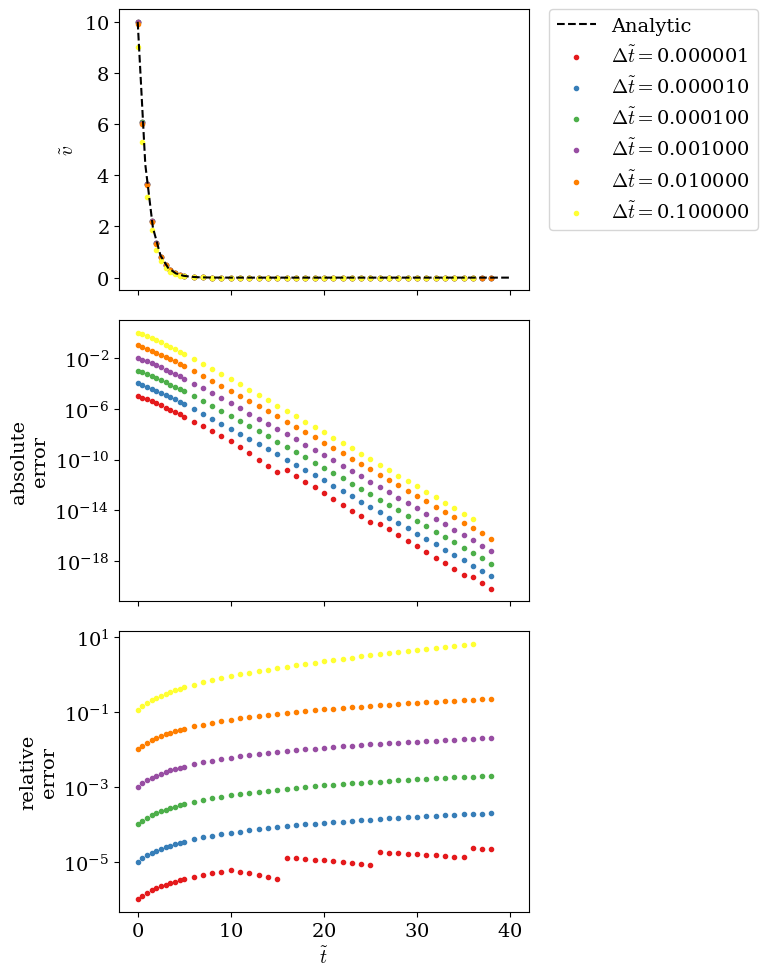

In [220]:
dtlist = []
tlist = []
vlist = []

fig, ax = plt.subplots(3,1,figsize=(8,10), sharex=True)
tTemp = np.linspace(0,40,50)
ax[0].plot(tTemp, vAnalytic(tTemp),color='black',ls='dashed', label = 'Analytic')


i = files[0]
for i in files:
    dt,t,v = graph(i)
    dtlist.append(float(dt))
    tlist.append(t[20])
    vlist.append(v[20])
    Label = r"$\Delta \tilde{t} = $"+dt
    ax[0].scatter(t,v,marker='.',label=Label)
    ax[1].scatter(t,np.abs(v-vAnalytic(t)),marker='.', label=Label)
    ax[2].scatter(t,np.abs(1-vAnalytic(t)/v),marker='.', label=Label)


ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax[0].set_ylabel(r'$\tilde{v}$')
ax[1].set_ylabel('absolute\nerror')
ax[1].set_yscale('log')
ax[2].set_yscale('log')
ax[2].set_ylabel('relative\nerror')
ax[2].set_xlabel(r'$\tilde{t}$')

dtlist = np.array(dtlist)
tlist = np.array(tlist)
vlist = np.array(vlist)
fig.tight_layout()
fig.savefig("./image/v.png")

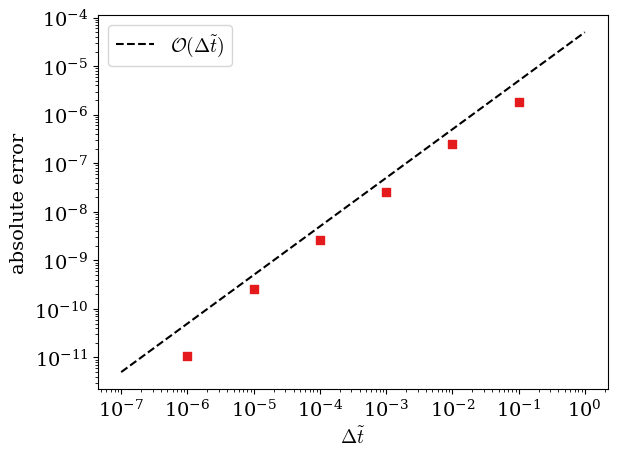

In [221]:
X = np.logspace(-7,0)
plt.scatter(dtlist,np.abs(vlist-vAnalytic(tlist)),marker='s')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r"$\Delta \tilde{t}$")
plt.ylabel(r"absolute error")
plt.plot(X,5e-5*X,color='black', ls='dashed', label=r"$\mathcal{O}(\Delta \tilde{t})$")
plt.legend()
plt.tight_layout()
plt.savefig("./image/dt.png")